# **Исследовательский проект по анализу полученных с сайта Кинопоиск данных о фильмах**

Егоров Алексей Игоревич, 2026

Курс: Технологии анализа данных, ИТМО

**Задача:**
На основе пройденного материала написать функцию для парсинга сайта Кинопоиск, создание и обработку полученого датасета, построение графиков и модели (через бесплатный API и обработка полученных результатов). Изучение корреляции региональной и международной оценки, влияния на оценку голосов зрителей.
Задача покрывает весь цикл обучение - от получения данных до интерпретации результатов.

Почта:
ignissopitus@yandex.ru

Телефон:
8-988-491-0532


In [226]:
import http.client
import csv
import json
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка и предварительная обработка данных

**1**. Парсинг сайта кинопоиска для получения сырых данных о фильмах. Имея бесплатный доступ к API сайта, доступен лимит в 200 запросов в день. Этого вполне достаточно, чтобы получить данные более чем на 30к строк.

Функция отработала отдельно, полученный датасет прилагается.

In [227]:
TOKEN = '' # Вставить свой токен.
LIMIT = 100

# Парсер сайта
def simple_parser(token, next_page=None):
    '''
    Функция обрабатывает полученные через бесплатный кинопоиск API 250 строк фильмов длиной от 60 до 250 минут, бюджетом
    от 1_000_000 до 1_000_000_000, и 2010-2020 года. Функия возвращает id, название, жанр, страну, рейтинги imdb,
    рейтинг кинопоиска, количество голосов, год. Сырые данные сбрасывает в csv файл для дальнейшей обработки. Возвращаемое значение - ключ
    следующей страницы, если такая имеется.
    Бесплатный доступ позволяет в сутки до 200 обращений к сайту.
    :param token:
      str: код токена
    :param nex_page
      str: при наличии - код страницы
    :return:
      str: код следующей страницы, полученный во время парсингаб передаваемый в функцию в цикле
    '''

    conn = http.client.HTTPSConnection('api.poiskkino.dev')
    headers = { 'X-API-KEY': token}

    if not next_page:
        pars_string = f'/v1.5/movie?year=2021&movieLength=60-250&isSeries=false&&budget.value=1000000-1000000000&year=2010-2020&limit=250'

    else:
        pars_string = f'/v1.5/movie?year=2021&movieLength=60-250&isSeries=false&&budget.value=1000000-1000000000&year=2010-2020&limit=250&next={next_page}'

    conn.request("GET", pars_string, headers=headers)
    response = conn.getresponse()
    response_bytes = response.read()
    data = response_bytes.decode('utf-8')

    res = json.loads(data)
    # Создаем файл с заголовком
    with open('row_data_kinopoick.csv', mode='w+', newline='', encoding='utf-8') as file:
        fieldnames = ['id', 'title', 'genres', 'countries', 'rating_kp', 'rating imdb', 'votes imdb', 'year']
        csv.DictWriter(file, fieldnames=fieldnames)

    # После каждого прохода функции дополняем файл полученными строками
    with open('row_data_kinopoick.csv', mode='a+', newline='', encoding='utf-8') as file:
        fieldnames = ['id', 'title', 'genres', 'countries', 'rating_kp', 'rating imdb', 'votes imdb', 'year']
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        writer.writeheader()

        for elem in res['docs']:
            try:
                writer.writerow({'id': elem['id'], 'title': elem['alternativeName'], 'genres': elem['genres'][0]['name'],
                            'countries': elem['countries'][0]['name'],'rating_kp': elem['rating']['kp'],
                             'rating imdb': elem['rating']['imdb'], 'votes imdb': elem['votes']['imdb'], 'year': elem['year']})
            except KeyError:
                continue

    # Проверка наличия следующей страницы.
    if not res['hasNext']:
        return
    return res['next']

# Функция для автоматического перелистывания страниц, падает на момент достижения лимита.
#for _ in range(LIMIT):
#    next_page = simple_parser(TOKEN)
#    if next_page:
#        simple_parser(TOKEN, next_page)


In [228]:
data_frame = pd.read_csv('row_data_kinopoisk.csv')
data_frame

,id,title,genres,countries,rating_kp,rating imdb,votes imdb,year
0,1355290,Deep Blue Sea 3,ужасы,США,4.691,4.7,8000,2020
1,1163914,Death of a Nation,документальный,США,0.000,4.1,7500,2018
2,1150478,Tales from the Hood 2,ужасы,США,0.000,4.4,2600,2018
3,1104616,Papita 2da Base,мелодрама,Венесуэла,0.000,6.0,196,2017
4,1104149,Kill Skills,триллер,Франция,0.000,6.1,149,2016
...,...,...,...,...,...,...,...,...
35175,1127372,Томирис,биография,Казахстан,7.872,6.3,44000,2019
35176,1125892,Nightmare Alley,триллер,США,7.054,7.0,182000,2021
35177,1125418,Hitman's Wife's Bodyguard,боевик,Великобритания,6.863,6.1,119000,2020
35178,1125423,Annabelle Comes Home,ужасы,США,5.926,5.9,101000,2019


# Описание набора данных
*   id - код фильма на сайте
*   title - название фильма
*   genres - жанр
*   countries - страна
*   rating_kp - рейтинг Кинопоиска
*   rating imdb - рейтинг imdb
*   votes imdb - количество голосов зрителей на imdb
*   year - год

В изначальной функции неверно названы столбцы : rating imdb и votes imdb, переименуем их.

In [229]:
data_frame = data_frame.rename(columns={'rating imdb': 'rating_imdb', 'votes imdb': 'votes_imdb'})

In [230]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35180 entries, 0 to 35179
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           35180 non-null  int64  
 1   title        35180 non-null  object 
 2   genres       35180 non-null  object 
 3   countries    35180 non-null  object 
 4   rating_kp    35180 non-null  float64
 5   rating_imdb  35180 non-null  float64
 6   votes_imdb   35180 non-null  int64  
 7   year         35180 non-null  int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 2.1+ MB


С помощью функции получено более 35к строк. Из них уникальных 499. Очевидно, фукнция собрала повторяемые значения во время прохода. Необходимо изменить строку с датойб и при каждом проходе в цикле менять год, чтобы получать валидные данные. Возможно, дело не в этом, а в ограничениях бесплатного доступа. Но для учебного проекта решено использовать 499 значений, так как этого будет достаточно для необходимого результата.

Видно, что отсутствующих значений в таблице нет.
Все фильмы имеют рейтинг;

*   Все имеют год;
*   Все имеют жанр;
*   Все фильмы имеют рейтинг;

Получен чистый датасет.

Отбросим дубликаты, продолжим обработку.

In [231]:
data_frame = data_frame.drop_duplicates(subset=['id'], keep='last')
data_frame.reset_index(drop=True, inplace=True)
data_frame

,id,title,genres,countries,rating_kp,rating_imdb,votes_imdb,year
0,1122117,Peter Rabbit 2: The Runaway,фэнтези,США,7.358,6.2,17000,2020
1,1122140,Jin ji jiu yuan,боевик,Китай,6.265,6.0,1200,2020
2,1122129,The Hunt,боевик,Китай,6.647,6.6,152000,2019
3,1122114,A Dog's Journey,фэнтези,США,8.078,7.5,33000,2019
4,1121425,Happy Death Day 2 U,ужасы,США,6.210,6.2,95000,2019
...,...,...,...,...,...,...,...,...
494,1127372,Томирис,биография,Казахстан,7.872,6.3,44000,2019
495,1125892,Nightmare Alley,триллер,США,7.054,7.0,182000,2021
496,1125418,Hitman's Wife's Bodyguard,боевик,Великобритания,6.863,6.1,119000,2020
497,1125423,Annabelle Comes Home,ужасы,США,5.926,5.9,101000,2019


**2.** Построим графики рейтингов фильмов.


Text(0, 0.5, 'Количество')

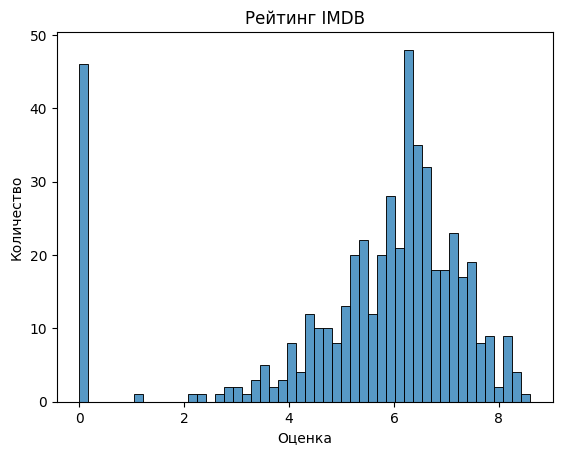

In [232]:
sns.histplot(data_frame['rating_imdb'], bins=50)
plt.title('Рейтинг IMDB')
plt.xlabel('Оценка')
plt.ylabel('Количество')

Построим график рейтинга кинопоиска.

Text(0, 0.5, 'Количество')

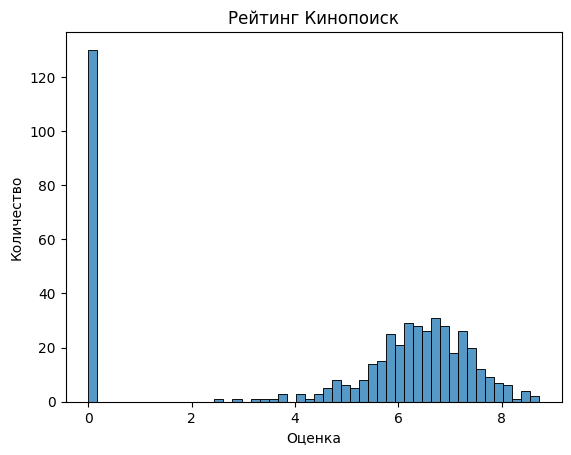

In [233]:
sns.histplot(data_frame['rating_kp'], bins=50)
plt.title('Рейтинг Кинопоиск')
plt.xlabel('Оценка')
plt.ylabel('Количество')

Из графика видно, что рейтинг большинства фильмов находится в диапазоне 5-7. Фильмов больше 8 - намного меньше.
Имеются фильмы с 0 оценкой, предположим, что это отстутсвующие значения из базы данных. Их следует удалить, для дальнейшей обработки.

In [234]:
data_frame_filtered = data_frame[(data_frame['rating_imdb'] > 0) & (data_frame['rating_kp'] > 0)]
data_frame_filtered

,id,title,genres,countries,rating_kp,rating_imdb,votes_imdb,year
0,1122117,Peter Rabbit 2: The Runaway,фэнтези,США,7.358,6.2,17000,2020
1,1122140,Jin ji jiu yuan,боевик,Китай,6.265,6.0,1200,2020
2,1122129,The Hunt,боевик,Китай,6.647,6.6,152000,2019
3,1122114,A Dog's Journey,фэнтези,США,8.078,7.5,33000,2019
4,1121425,Happy Death Day 2 U,ужасы,США,6.210,6.2,95000,2019
...,...,...,...,...,...,...,...,...
494,1127372,Томирис,биография,Казахстан,7.872,6.3,44000,2019
495,1125892,Nightmare Alley,триллер,США,7.054,7.0,182000,2021
496,1125418,Hitman's Wife's Bodyguard,боевик,Великобритания,6.863,6.1,119000,2020
497,1125423,Annabelle Comes Home,ужасы,США,5.926,5.9,101000,2019


In [235]:
data_frame_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 343 entries, 0 to 498
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           343 non-null    int64  
 1   title        343 non-null    object 
 2   genres       343 non-null    object 
 3   countries    343 non-null    object 
 4   rating_kp    343 non-null    float64
 5   rating_imdb  343 non-null    float64
 6   votes_imdb   343 non-null    int64  
 7   year         343 non-null    int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 24.1+ KB


**3.** Произведем сравнение международного и регионального рейтинга, добавим новый столбец с полученной разницей.

In [236]:
data_frame_filtered['rating_diff'] = abs(data_frame_filtered['rating_kp'] - data_frame_filtered['rating_imdb'])

/tmp/ipykernel_267/2875718266.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_frame_filtered['rating_diff'] = abs(data_frame_filtered['rating_kp'] - data_frame_filtered['rating_imdb'])


Фильмы с самой большой и наименьшей разницей рейтингов.

In [237]:
data_frame_filtered.sort_values('rating_diff')

,id,title,genres,countries,rating_kp,rating_imdb,votes_imdb,year,rating_diff
395,1219149,Shang-Chi and the Legend of the Ten Rings,фэнтези,США,7.300,7.3,484000,2021,0.000
412,1200603,Hustlers,комедия,США,6.303,6.3,112000,2019,0.003
385,1228050,Injil,триллер,Корея Южная,6.294,6.3,1300,2021,0.006
67,1108495,The Aeronauts,приключения,Великобритания,6.591,6.6,40000,2019,0.009
249,1355290,Deep Blue Sea 3,ужасы,США,4.691,4.7,8000,2020,0.009
...,...,...,...,...,...,...,...,...,...
16,1115685,Фиксики против кработов,мультфильм,Россия,8.101,5.7,178,2019,2.401
360,1249181,Барбоскины на даче,мультфильм,Россия,8.417,5.6,118,2020,2.817
64,1108921,Wheely,мультфильм,Малайзия,7.254,4.1,762,2018,3.154
331,1273240,Новогодний ремонт,комедия,Россия,6.542,2.9,147,2019,3.642


Десять фильмов с максимальной разницей.

In [238]:
data_frame_filtered.sort_values('rating_diff', ascending=False).head(10)

,id,title,genres,countries,rating_kp,rating_imdb,votes_imdb,year,rating_diff
416,1199529,Донбасс. Окраина,драма,Россия,7.425,3.7,446,2018,3.725
331,1273240,Новогодний ремонт,комедия,Россия,6.542,2.9,147,2019,3.642
64,1108921,Wheely,мультфильм,Малайзия,7.254,4.1,762,2018,3.154
360,1249181,Барбоскины на даче,мультфильм,Россия,8.417,5.6,118,2020,2.817
16,1115685,Фиксики против кработов,мультфильм,Россия,8.101,5.7,178,2019,2.401
103,1102458,Cinderella and the Secret Prince,мультфильм,США,6.683,4.4,852,2018,2.283
125,1098963,Sex and the Future,комедия,США,4.383,2.2,440,2020,2.183
333,1272474,Спасите Колю!,комедия,Россия,6.770,4.6,126,2020,2.170
217,634268,Rowdy Rathore,боевик,Индия,7.841,5.8,27000,2012,2.041
38,1113011,Конь Юлий и большие скачки,мультфильм,Россия,7.411,5.4,416,2020,2.011


Выделим 10 фильмов, имеющих максимальное количество голосов зрителей. Предположительно, это самые кассовые фильмы.

In [239]:
data_frame_filtered.sort_values('votes_imdb', ascending=False).head(10)

,id,title,genres,countries,rating_kp,rating_imdb,votes_imdb,year,rating_diff
297,1309570,Spider-Man: No Way Home,фантастика,США,7.926,8.1,1000000,2021,0.174
155,679830,Avengers: Age of Ultron,фантастика,США,7.257,7.3,994000,2015,0.043
435,1188529,Knives Out,детектив,США,8.188,7.9,870000,2019,0.288
457,1171976,1917,военный,Великобритания,7.932,8.2,764000,2019,0.268
160,679486,Coco,мультфильм,США,8.726,8.4,698000,2017,0.326
375,1236063,Tenet,фантастика,Великобритания,7.524,7.3,679000,2020,0.224
68,1108577,Green Book,биография,США,8.547,8.2,677000,2018,0.347
277,1338480,Don't Look Up,драма,США,7.478,7.1,666000,2021,0.378
283,1322324,Everything Everywhere All at Once,фантастика,США,7.191,7.7,623000,2021,0.509
417,1199100,Free Guy,фантастика,США,7.366,7.1,484000,2021,0.266


Построим графики пересечения рейтингов Кинопоиска и IMDB

<Axes: xlabel='rating_imdb', ylabel='rating_kp'>

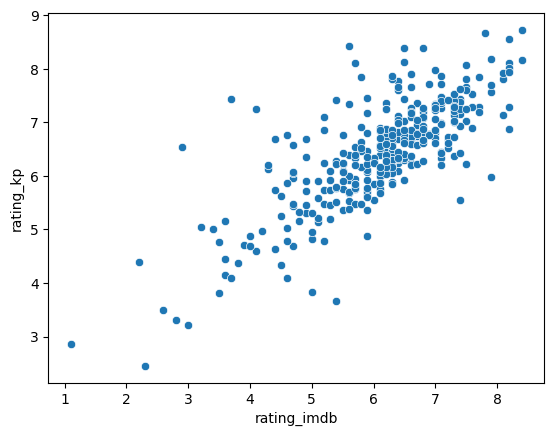

In [240]:
sns.scatterplot(x='rating_imdb', y='rating_kp', data=data_frame_filtered)

<Axes: >

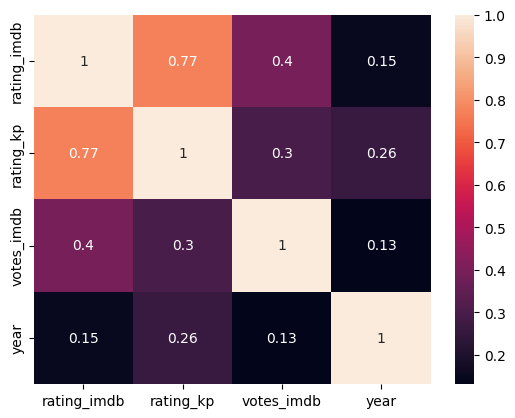

In [241]:
corr = data_frame_filtered[['rating_imdb', 'rating_kp', 'votes_imdb', 'year']].corr()

sns.heatmap(corr, annot=True)

# Корреляционный анализ

Видна высокая положительная корреляция (0.77) рейтингов регионального и международного. Но корреляция не равна 1, что указывает на существование фильмов по-разному оцениваемых зрителями или отсутствие данных.

У связи рейтинга и голосов незначительная корреляция (0.40). Это указывает на то, что более популярные фильмы имеют большее количество голосов зрителей. Можно отметить, что популярность не указывает на качество фильма.
К сожалению, для анализа нет возможности получить голоса зрителей Кинопоиска, имея только бесплатный доступ. Так что данная корреляция (голоса/рейтинг Кинопоиска) не имеет значения.

Год и количество голосов вообще не имеют связи. Скорее тут наблюдается развитие информационных технологий и большего доступа/интереса зрителей к интернет ресурсам.



**Скрытые сокровища**

Из полученного датасета выделим фильмы, имеющие высокую оценку, но небольшое количество голосов. Возможно, эти фильмы достойны внимания.

In [242]:
data_frame_filtered[(data_frame_filtered['rating_imdb'] > 7) & (data_frame_filtered['votes_imdb'] < 3000)]

,id,title,genres,countries,rating_kp,rating_imdb,votes_imdb,year,rating_diff
228,633958,Despre oameni şi melci,комедия,Румыния,6.717,7.2,2500,2012,0.483
286,1320548,Маленький воин,семейный,Россия,6.222,7.5,97,2021,1.278
317,1288108,Jasaneobo,биография,Корея Южная,7.020,7.5,1000,2021,0.480
371,1237995,Dambo,драма,Корея Южная,7.843,7.7,2200,2020,0.143
409,1206600,Eorin uiroein,драма,Корея Южная,7.613,7.4,1600,2019,0.213


Из 5 полученных фильмов, 3 принадлежат Южной Корее, что возможно указывает на возросший интерес к азиатской культуре или общее качество продукции.

# Модель линейной регрессии

**4.** Построим модель линейной регрессии для предсказания рейтинга IMDb.

Попробуем предсказать рейтинг IMDb на основе:
*   Года
*   Рейтинга
*   Количества голосов




In [243]:
X = data_frame_filtered[['votes_imdb', 'year']]
y = data_frame_filtered['rating_imdb']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [244]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

In [247]:
round(mean_absolute_error(y_test, pred), 3)

0.752

# Интерпретация результатов

Модель показала среднюю абсолютную ошибку 0.75, что означает:

Прогнозируемые оценки отличаются от фактических оценок IMDb в среднем примерно на три четверти балла. Модель улавила общий тренд данных связи голосов зрителей и оценки, но не может точно предсказать рейтинг каждого фильма.
Причины банальны:
*   Небольшой датасет (проблема фильтраци при парсинге)
*   Ограниченное количество числовых признаков
*   Рейтинг зависит от факторов, которых нет в данных

На увеличение качества модели положительно сказались бы данные о бюджете фильма, но в бесплатном доступе к API их получить не получилось. Так же интересно было бы получить данные о количестве голосов оставленных зрителями непосредственно на сайте Кинопоиска.

Построим график для полученной модели.

Text(0, 0.5, 'предсказание')

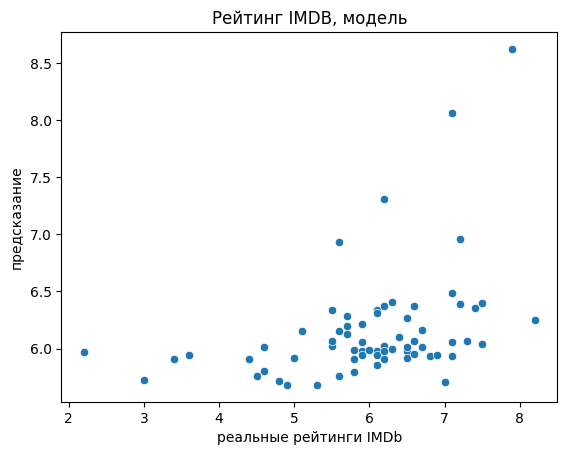

In [253]:
sns.scatterplot(x=y_test,y=pred)
plt.title('Рейтинг IMDB, модель')
plt.xlabel('реальные рейтинги IMDb')
plt.ylabel('предсказание')


Диаграмма рассеяния сравнивает фактические рейтинги IMDb с рейтингами, предсказанными регрессионной моделью.
В идеале все точки должны лежать на диагональной линии, где предсказанные значения равны фактическим значениям.
На этом графике большинство точек расположены вблизи диагональной линии, что указывает на то, что предсказания модели достаточно близки к истинным рейтингам.
Однако видны отклонения, особенно для фильмов с очень низкими или очень высокими рейтингами. Это говорит о том, что модель немного испытывает трудности с экстремальными значениями.